# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 48.2 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# Import counter
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
# Loading dataset
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('fatal-police-shootings-data.csv', encoding="utf-8")  # use utf-8 due to error in the data
df_agencies = pd.read_csv('fatal-police-shootings-agencies.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
## viewing the data, household income data
df_hh_income.head()

,Geographic Area,City,Median Income
0,AL,Abanda CDP,11207
1,AL,Abbeville city,25615
2,AL,Adamsville city,42575
3,AL,Addison town,37083
4,AL,Akron town,21667


In [6]:
# ppl poverty level data
df_pct_poverty.head()

,Geographic Area,City,poverty_rate
0,AL,Abanda CDP,78.8
1,AL,Abbeville city,29.1
2,AL,Adamsville city,25.5
3,AL,Addison town,30.7
4,AL,Akron town,42


In [7]:
# pct completed high school data
df_pct_completed_hs.head()

,Geographic Area,City,percent_completed_hs
0,AL,Abanda CDP,21.2
1,AL,Abbeville city,69.1
2,AL,Adamsville city,78.9
3,AL,Addison town,81.4
4,AL,Akron town,68.6


In [8]:
# shape of ratio by race in city
df_share_race_city

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AL,Abanda CDP,67.2,30.2,0,0,1.6
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3
3,AL,Addison town,99.1,0.1,0,0.1,0.4
4,AL,Akron town,13.2,86.5,0,0,0.3
...,...,...,...,...,...,...,...
29263,WY,Woods Landing-Jelm CDP,95.9,0,0,2.1,0
29264,WY,Worland city,89.9,0.3,1.3,0.6,16.6
29265,WY,Wright town,94.5,0.1,1.4,0.2,6.2
29266,WY,Yoder town,97.4,0,0,0,4


In [9]:
# death by police in US
df_fatalities.head()

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,location_precision,name,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids
0,3,2015-01-02,point,not,gun,Shelton,Mason,WA,47.25,-123.12,not_available,Tim Elliot,53.00,male,A,not_available,True,False,73
1,4,2015-01-02,point,not,gun,Aloha,Washington,OR,45.49,-122.89,not_available,Lewis Lee Lembke,47.00,male,W,not_available,False,False,70
2,5,2015-01-03,move,not,unarmed,Wichita,Sedgwick,KS,37.69,-97.28,not_available,John Paul Quintero,23.00,male,H,not_available,False,False,238
3,8,2015-01-04,point,not,replica,San Francisco,San Francisco,CA,37.76,-122.42,not_available,Matthew Hoffman,32.00,male,W,not_available,True,False,196
4,9,2015-01-04,point,not,other,Evans,Weld,CO,40.38,-104.69,not_available,Michael Rodriguez,39.00,male,H,not_available,False,False,473


In [10]:
# Police Agencies
df_agencies.head()

,id,name,type,state,oricodes,total_shootings
0,3145,Abbeville County Sheriff's Office,sheriff,SC,SC00100,1
1,2576,Aberdeen Police Department,local_police,WA,WA01401,1
2,2114,Abilene Police Department,local_police,TX,TX22101,8
3,2088,Abington Township Police Department,local_police,PA,PA04601,1
4,3187,Acadia Parish Sheriff's Office,sheriff,LA,LA00100,1


### Exploring the data; checking the shape, column names, duplicates and NaN values


In [11]:
## household income data

print(f"shape: \n{df_hh_income.shape}")
print(f"\ncolumn names: \n{df_hh_income.columns}")
print(f"\nNaN values: \n{df_hh_income.isna().sum()}")
print(f"\nduplicates: \n{df_hh_income.duplicated().sum()}")


shape: 
(29322, 3)

column names: 
Index(['Geographic Area', 'City', 'Median Income'], dtype='object')

NaN values: 
Geographic Area     0
City                0
Median Income      51
dtype: int64

duplicates: 
0


In [12]:
## ppl poverty level data

print(f"shape: \n{df_pct_poverty.shape}")
print(f"\ncolumn names: \n{df_pct_poverty.columns}")
print(f"\nNaN values: \n{df_pct_poverty.isna().sum()}")
print(f"\nduplicates: \n{df_pct_poverty.duplicated().sum()}")

shape: 
(29329, 3)

column names: 
Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object')

NaN values: 
Geographic Area    0
City               0
poverty_rate       0
dtype: int64

duplicates: 
0


In [13]:
## pct completed high school data

print(f"shape: \n{df_pct_completed_hs.shape}")
print(f"\ncolumn names: \n{df_pct_completed_hs.columns}")
print(f"\nNaN values: \n{df_pct_completed_hs.isna().sum()}")
print(f"\nduplicates: \n{df_pct_completed_hs.duplicated().sum()}")

shape: 
(29329, 3)

column names: 
Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object')

NaN values: 
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64

duplicates: 
0


In [14]:
## shape of ratio by race in city

print(f"shape: \n{df_share_race_city.shape}")
print(f"\ncolumn names: \n{df_share_race_city.columns}")
print(f"\nNaN values: \n{df_share_race_city.isna().sum()}")
print(f"\nduplicates: \n{df_share_race_city.duplicated().sum()}")

shape: 
(29268, 7)

column names: 
Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object')

NaN values: 
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64

duplicates: 
0


In [15]:
## death by police in US

print(f"shape: \n{df_fatalities.shape}")
print(f"\ncolumn names: \n{df_fatalities.columns}")
print(f"\nNaN values: \n{df_fatalities.isna().sum()}")
print(f"\nduplicates: \n{df_fatalities.duplicated().sum()}")

shape: 
(10430, 19)

column names: 
Index(['id', 'date', 'threat_type', 'flee_status', 'armed_with', 'city',
       'county', 'state', 'latitude', 'longitude', 'location_precision',
       'name', 'age', 'gender', 'race', 'race_source',
       'was_mental_illness_related', 'body_camera', 'agency_ids'],
      dtype='object')

NaN values: 
id                               0
date                             0
threat_type                     68
flee_status                   1491
armed_with                     211
city                            74
county                        4691
state                            0
latitude                      1140
longitude                     1141
location_precision            1140
name                           318
age                            372
gender                          20
race                          1188
race_source                   1166
was_mental_illness_related       0
body_camera                      0
agency_ids                    

In [16]:
## police agencies

print(f"shape: \n{df_agencies.shape}")
print(f"\ncolumn names: \n{df_agencies.columns}")
print(f"\nNaN values: \n{df_agencies.isna().sum()}")
print(f"\nduplicates: \n{df_agencies.duplicated().sum()}")

shape: 
(3727, 6)

column names: 
Index(['id', 'name', 'type', 'state', 'oricodes', 'total_shootings'], dtype='object')

NaN values: 
id                   0
name                 0
type                 1
state                0
oricodes           132
total_shootings      0
dtype: int64

duplicates: 
0


## Data Cleaning - Check for Missing Values

Dealing with the NaN values. Some NaN values are retained to prevent distortion of data. Absence of data does not imply zero (0). The missing household income are imputed with median to preserve central tendency.

Household Income

In [17]:
## Replacing Household income values with the median of the household income

df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors="coerce")
median_income = df_hh_income["Median Income"].median()
df_hh_income['Median Income'] = df_hh_income['Median Income'].fillna(median_income)

df_hh_income.head()


,Geographic Area,City,Median Income
0,AL,Abanda CDP,"11,207.00"
1,AL,Abbeville city,"25,615.00"
2,AL,Adamsville city,"42,575.00"
3,AL,Addison town,"37,083.00"
4,AL,Akron town,"21,667.00"


Percent Completed High School

In [18]:
non_numeric = df_pct_completed_hs[
    pd.to_numeric(df_pct_completed_hs["percent_completed_hs"], errors="coerce").isna()
]

non_numeric.head()

,Geographic Area,City,percent_completed_hs
573,AL,Whatley CDP,-
632,AK,Chicken CDP,-
637,AK,Chisana CDP,-
662,AK,Dot Lake CDP,-
667,AK,Edna Bay city,-


In [19]:
## Changing the datatype of percent_complete_hs to numeric
df_pct_completed_hs["percent_completed_hs"] = pd.to_numeric(df_pct_completed_hs["percent_completed_hs"], errors="coerce")

print(df_pct_completed_hs["percent_completed_hs"].dtype)
print(df_pct_completed_hs.isna().sum())

float64
Geographic Area           0
City                      0
percent_completed_hs    197
dtype: int64


Poverty Rates

In [20]:
# Converting the poverty_rate to numeric
df_pct_poverty["poverty_rate"] = pd.to_numeric(df_pct_poverty["poverty_rate"], errors="coerce")
print(df_pct_poverty["poverty_rate"].dtype)


float64


In [21]:
# Count the number of column with NaN values
df_pct_poverty.isna().sum()

,0
Geographic Area,0
City,0
poverty_rate,201


Police fatalities

In [22]:
# Inspect the fatalities table information
df_fatalities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10430 entries, 0 to 10429
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10430 non-null  int64  
 1   date                        10430 non-null  object 
 2   threat_type                 10362 non-null  object 
 3   flee_status                 8939 non-null   object 
 4   armed_with                  10219 non-null  object 
 5   city                        10356 non-null  object 
 6   county                      5739 non-null   object 
 7   state                       10430 non-null  object 
 8   latitude                    9290 non-null   float64
 9   longitude                   9289 non-null   float64
 10  location_precision          9290 non-null   object 
 11  name                        10112 non-null  object 
 12  age                         10058 non-null  float64
 13  gender                      104

In [23]:
# Cleaning the category columns
category_col = ["threat_type", "flee_status", "armed_with", "city", "county", "location_precision", "gender", "race", "race_source"]

df_fatalities[category_col] = df_fatalities[category_col].fillna("unknown")

# Check for Nan values after filling with "unknown"
print(df_fatalities[category_col].isna().any().any())

False


In [24]:
# Row with multiple agency_ids linked to a fatality
multiple_agencies = df_fatalities[df_fatalities["agency_ids"].astype(str).str.contains(";")]

multiple_agencies[["agency_ids"]].head()

,agency_ids
18,491;492
31,228;229
61,1953;109
66,174;175
71,512;511


#### Agencies

In [25]:
print(f"\nNaN values: \n{df_agencies.isna().sum()}")


NaN values: 
id                   0
name                 0
type                 1
state                0
oricodes           132
total_shootings      0
dtype: int64


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [26]:
df_pct_poverty.head()


,Geographic Area,City,poverty_rate
0,AL,Abanda CDP,78.80
1,AL,Abbeville city,29.10
2,AL,Adamsville city,25.50
3,AL,Addison town,30.70
4,AL,Akron town,42.00


In [27]:
# grouping the poverty rate by state
pov_rate = df_pct_poverty.groupby("Geographic Area").agg({"poverty_rate": pd.Series.mean}).sort_values(by="poverty_rate", ascending=False, )

# Highest and lowest poverty rates
top_bottom = pd.concat([pov_rate.head(1), pov_rate.tail(1)])
print(top_bottom)


                 poverty_rate
Geographic Area              
MS                      26.88
NJ                       8.19


In [28]:
# creating a bar chart of the poverty rate
pov_rate.sort_values(by="poverty_rate", ascending=False, )
bar = px.bar(pov_rate,
             x=pov_rate.index,
             y="poverty_rate",
             title="Poverty Rate by State")
bar.update_layout(
    xaxis_title="US States",
    yaxis_title="% Poverty Rate")
bar.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [29]:
# Graduation Rate in ascending order by States
hs_grad_rate = df_pct_completed_hs.groupby("Geographic Area").agg({"percent_completed_hs": pd.Series.mean}).sort_values(by="percent_completed_hs", ascending=True)
hs_grad_rate.head()


,percent_completed_hs
Geographic Area,
TX,75.69
MS,78.47
GA,79.01
LA,79.29
AR,79.95


In [30]:
# Using a bar chart to visualize from lowest hs graduation rate to highest
hs_grad_rate.sort_values(by="percent_completed_hs", ascending=True) # sorting by pct high sch grad

bar = px.bar(hs_grad_rate,
             x=hs_grad_rate.index,
             y="percent_completed_hs",
             title="High School Graduation Rate by States")
bar.update_layout(
    xaxis_title="US States",
    yaxis_title="% Completed High School",
    yaxis=dict(
        range=[60, 95],   # Start at 60, end at 95
        dtick=5           # Tick interval of 5
    )
)

bar.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [31]:
# Sorting the poverty rate by geographic area, the common denominator btw pov rates and high sch grad rates
pov_rate = pov_rate.sort_values(by="Geographic Area", ascending=True)
pov_rate.head()

,poverty_rate
Geographic Area,
AK,19.85
AL,20.65
AR,22.96
AZ,25.67
CA,17.12


In [32]:
# Sorting the high sch grad rates by geographic area
hs_grad_rate = hs_grad_rate.sort_values(by="Geographic Area", ascending=True)
hs_grad_rate.head()

,percent_completed_hs
Geographic Area,
AK,84.63
AL,80.30
AR,79.95
AZ,80.47
CA,81.96


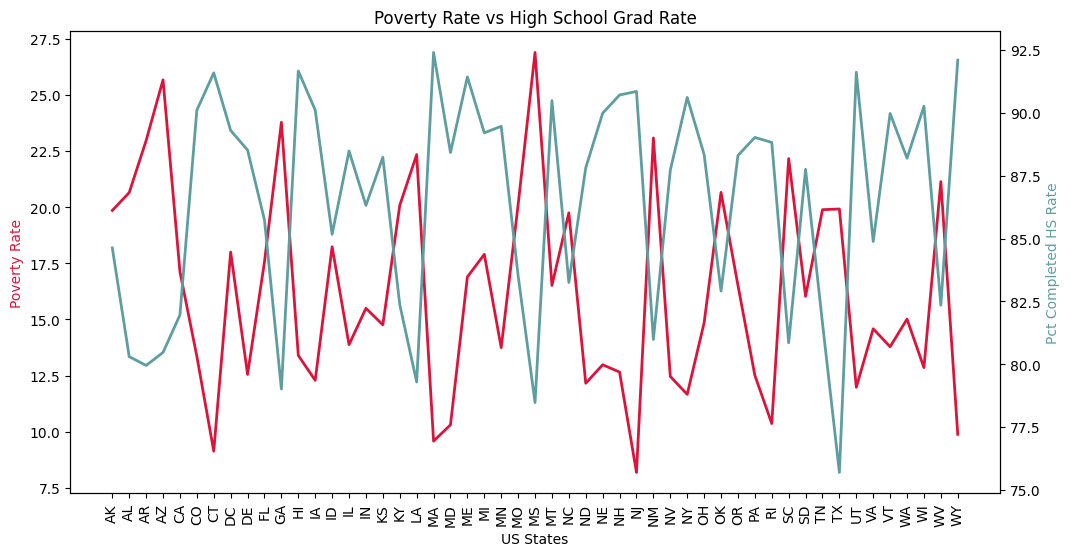

In [33]:
# Creating a line chart showing the r/s between poverty rates and high sch grad rate

us_states = hs_grad_rate.index   # common index to be used as the x-axis

plt.figure(figsize=(12,6))
plt.title("Poverty Rate vs High School Grad Rate", fontsize=12)
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)

ax1 = plt.gca() #get current axis
ax2 = plt.twinx() #create another plot using the same x-axis

ax1.set_xlabel("US States", fontsize=10)
ax1.set_ylabel("Poverty Rate", color="crimson", fontsize=10)

ax2.set_ylabel("Pct Completed HS Rate", color="cadetblue", fontsize=10)

ax1.plot(pov_rate.index, pov_rate['poverty_rate'], linewidth=2, color="crimson")
ax2.plot(hs_grad_rate.index, hs_grad_rate['percent_completed_hs'], linewidth=2, color="cadetblue")

plt.show()

#### Use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

In [34]:
# Merging both pov_rate and high_sch_rate dfs
merged = pov_rate.merge(
    hs_grad_rate,
    left_index=True,
    right_index=True,
    how="inner"
)

print(merged.head())


                 poverty_rate  percent_completed_hs
Geographic Area                                    
AK                      19.85                 84.63
AL                      20.65                 80.30
AR                      22.96                 79.95
AZ                      25.67                 80.47
CA                      17.12                 81.96


In [35]:
# Creating a poverty level column using the median poverty rate
merged["poverty_level"] = merged["poverty_rate"].apply(
    lambda x: "High Poverty" if x > merged["poverty_rate"].median() else "Low Poverty"
)

print(merged.head())

                 poverty_rate  percent_completed_hs poverty_level
Geographic Area                                                  
AK                      19.85                 84.63  High Poverty
AL                      20.65                 80.30  High Poverty
AR                      22.96                 79.95  High Poverty
AZ                      25.67                 80.47  High Poverty
CA                      17.12                 81.96  High Poverty


<Figure size 768x576 with 0 Axes>

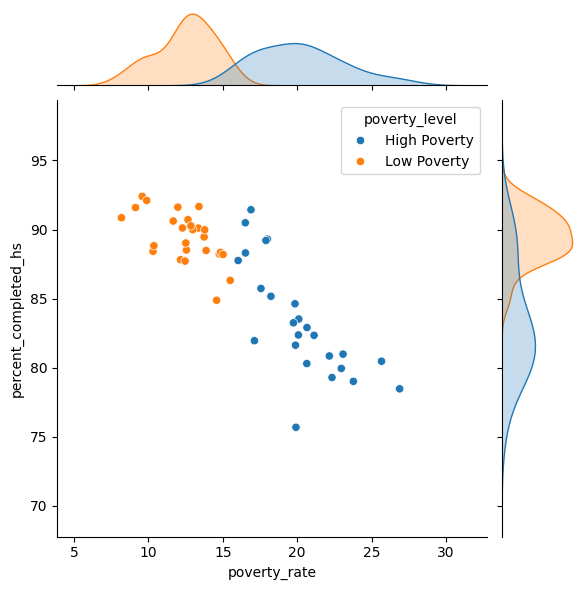

In [36]:
# jointplot() with kde
plt.figure(dpi=120)
sns.jointplot(
    data=merged,
    x="poverty_rate",
    y="percent_completed_hs",
    hue="poverty_level"
)

plt.show()


<Figure size 768x576 with 0 Axes>

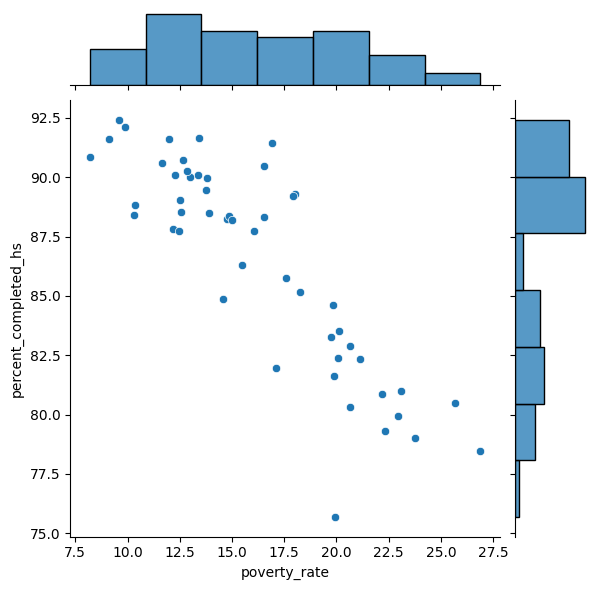

In [37]:
# jointplot() with scatterplot
plt.figure(dpi=120)
sns.jointplot(x=pov_rate.poverty_rate, y=hs_grad_rate.percent_completed_hs)
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

<Figure size 768x576 with 0 Axes>

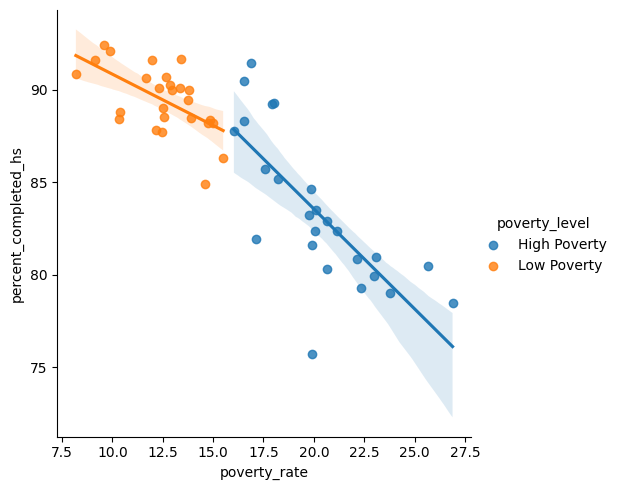

In [38]:
# Linear regression using implot
plt.figure(dpi=120)
sns.lmplot(
    data=merged,
    x="poverty_rate",
    y="percent_completed_hs",
    hue="poverty_level"
    )
plt.show()

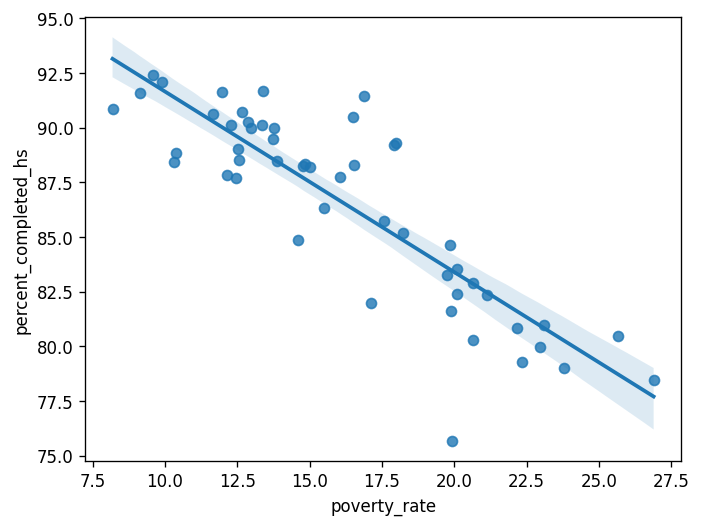

In [39]:
# Linear regression using regplot
plt.figure(dpi=120)
sns.regplot(
    x=pov_rate.poverty_rate,
    y=hs_grad_rate.percent_completed_hs,
    )
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

In [40]:
df_share_race_city.head()

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AL,Abanda CDP,67.2,30.2,0,0,1.6
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3
3,AL,Addison town,99.1,0.1,0,0.1,0.4
4,AL,Akron town,13.2,86.5,0,0,0.3


In [41]:
# converting the shared race column to numeric datatype
race_columns = ["share_white", "share_black", "share_native_american", "share_asian", "share_hispanic"]
for column in race_columns:
  df_share_race_city[column] = pd.to_numeric(df_share_race_city[column], errors="coerce")

df_share_race_city.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29268 entries, 0 to 29267
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Geographic area        29268 non-null  object 
 1   City                   29268 non-null  object 
 2   share_white            29248 non-null  float64
 3   share_black            29248 non-null  float64
 4   share_native_american  29248 non-null  float64
 5   share_asian            29248 non-null  float64
 6   share_hispanic         29248 non-null  float64
dtypes: float64(5), object(2)
memory usage: 1.6+ MB


In [42]:
# Checking for NaN values in the df
race_columns = ["share_white", "share_black", "share_native_american", "share_asian", "share_hispanic"]
for column in race_columns:
  print(f"{column}: {df_share_race_city[column].isna().sum()}")

share_white: 20
share_black: 20
share_native_american: 20
share_asian: 20
share_hispanic: 20


In [43]:
# Checking where the NaN values reside in the df
col_subsets = ["share_white", "share_black", "share_native_american", "share_asian", "share_hispanic"]
columns = ["Geographic area", "City"] + col_subsets
check_df = df_share_race_city.loc[df_share_race_city["share_white"].isna()][columns]
check_df.head()

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
630,AK,Chisana CDP,NaN,NaN,NaN,NaN,NaN
678,AK,Flat CDP,NaN,NaN,NaN,NaN,NaN
777,AK,Mertarvik CDP,NaN,NaN,NaN,NaN,NaN
1946,CA,Almanor CDP,NaN,NaN,NaN,NaN,NaN
2134,CA,Caribou CDP,NaN,NaN,NaN,NaN,NaN


In [44]:
# Mean of each race by Geographic area
race_by_state = df_share_race_city.groupby("Geographic area").agg(
    {"share_white": pd.Series.mean,
     "share_black": pd.Series.mean,
     "share_native_american": pd.Series.mean,
     "share_asian": pd.Series.mean,
     "share_hispanic": pd.Series.mean}
)
race_by_state.head()

,share_white,share_black,share_native_american,share_asian,share_hispanic
Geographic area,,,,,
AK,45.65,0.57,45.86,1.39,2.15
AL,72.51,23.32,0.66,0.48,2.98
AR,78.45,16.30,0.76,0.48,4.27
AZ,59.93,0.95,28.59,0.73,20.14
CA,71.87,2.69,1.72,5.57,29.65


In [45]:
# Bar chart showing the racial composition by state
race_by_state = race_by_state.rename(columns=lambda x: x.replace("share_", ""))   # Renaming the column headers

# Bar Chart
share_race = px.bar(race_by_state,
                  x = race_by_state.index,
                  y = ["white", "black", "native_american", "asian", "hispanic"],
                  barmode="stack",
                  title="Average City Racial Composition per US State",
                  height=450
                  )
share_race.update_layout(
    xaxis_title="US State",
    yaxis_title="% share index",
    xaxis={"categoryorder":"total descending"},
    xaxis_tickfont_size=11,
    yaxis=dict(type='log'),
    bargap=0.15,      # gap between groups
    legend_title_text=" "
    )
share_race.show()

# Create Donut Chart of People Killed by Race

Hint: Use `.value_counts()`

In [46]:
df_fatalities.head()

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,location_precision,name,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids
0,3,2015-01-02,point,not,gun,Shelton,Mason,WA,47.25,-123.12,not_available,Tim Elliot,53.00,male,A,not_available,True,False,73
1,4,2015-01-02,point,not,gun,Aloha,Washington,OR,45.49,-122.89,not_available,Lewis Lee Lembke,47.00,male,W,not_available,False,False,70
2,5,2015-01-03,move,not,unarmed,Wichita,Sedgwick,KS,37.69,-97.28,not_available,John Paul Quintero,23.00,male,H,not_available,False,False,238
3,8,2015-01-04,point,not,replica,San Francisco,San Francisco,CA,37.76,-122.42,not_available,Matthew Hoffman,32.00,male,W,not_available,True,False,196
4,9,2015-01-04,point,not,other,Evans,Weld,CO,40.38,-104.69,not_available,Michael Rodriguez,39.00,male,H,not_available,False,False,473


In [47]:
fatalities_by_race = df_fatalities["race"].value_counts()
fatalities_by_race

,count
race,
W,4659
B,2486
H,1717
unknown,1188
A,184
N,146
O,37
W;B,4
W;H,3


In [48]:
fatalities_by_race = fatalities_by_race.rename(index={"W": "White", "B": "Black", "H": "Hispanic", "A": "Asian", "N": "Native American",
                                                  "O": "Others", "W;B": "White/Black", "W;H": "White/Hispanic", "B;H": "Black/Hispanic",
                                                  "W;B;N": "White/Black/Native American", "N;H": "Native American/Hispanic", "W;A": "White/Asian"})
fatalities_by_race


,count
race,
White,4659
Black,2486
Hispanic,1717
unknown,1188
Asian,184
Native American,146
Others,37
White/Black,4
White/Hispanic,3


In [49]:
# donut chart showing racial killings
fig = px.pie(labels=fatalities_by_race.index,
             values=fatalities_by_race.values,
             title="Donut chart showing Racial Killings Across US",
             names=fatalities_by_race.index,
             hole=0.6
)
fig.update_traces(textposition="inside",
                  textinfo="percent+label",
                  textfont_size=15,
                  hovertemplate="Label: %{label}<br>" + "Shootings: %{value}<br>" + "Percentage: %{percent}")
fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women.

In [50]:
# Print the datatype of the gender column
print(f"Data type of Gender: {df_fatalities["gender"].map(type).unique()}")

# Converting the gender column to string as it contains mixed data type
df_fatalities["gender"] = df_fatalities["gender"].astype(str)
print(f"Gender column converted to : {df_fatalities["gender"].map(type).unique()}")

Data type of Gender: [<class 'str'>]
Gender column converted to : [<class 'str'>]


In [51]:
# Count of gender
gender_killings = df_fatalities["gender"].value_counts()

# Rename the gender index
gender_killings = gender_killings.rename(index={"male": "Male", "female": "Female", "unknown": "Unknown", "non-binary": "Non-Binary"})
gender_killings

,count
gender,
Male,9943
Female,462
Unknown,20
Non-Binary,5


In [52]:
# Bar chart showing the total number of deaths of men vs women
bar = px.bar(x = gender_killings.index,
             y = gender_killings.values,
             title = "Total Number of Deaths of Men vs Women",
             text = gender_killings.values)
bar.update_layout(xaxis_title="Gender",
                  yaxis_title="Count of Gender",
                  width=800,
                  height=600)
bar.update_traces(width=0.4, textposition="outside")
bar.show()

# Create a Box Plot Showing the Age and Threat Type

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the threat type?

In [53]:
# Create a copy of the df_fatalities
df_fatalities_copy = df_fatalities.copy()

# Remove the rows where gender is 0 and non binary
df_fatalities_gender = df_fatalities_copy.query("gender != 'unknown' and gender != 'non-binary'").copy()    # Using copy() to ensure that the new df created isn't a sliced copy of the old df
df_fatalities_gender['gender'] = df_fatalities_gender['gender'].replace({"male": "Male", 'female': "Female"})
df_fatalities_gender.head()

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,location_precision,name,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids
0,3,2015-01-02,point,not,gun,Shelton,Mason,WA,47.25,-123.12,not_available,Tim Elliot,53.00,Male,A,not_available,True,False,73
1,4,2015-01-02,point,not,gun,Aloha,Washington,OR,45.49,-122.89,not_available,Lewis Lee Lembke,47.00,Male,W,not_available,False,False,70
2,5,2015-01-03,move,not,unarmed,Wichita,Sedgwick,KS,37.69,-97.28,not_available,John Paul Quintero,23.00,Male,H,not_available,False,False,238
3,8,2015-01-04,point,not,replica,San Francisco,San Francisco,CA,37.76,-122.42,not_available,Matthew Hoffman,32.00,Male,W,not_available,True,False,196
4,9,2015-01-04,point,not,other,Evans,Weld,CO,40.38,-104.69,not_available,Michael Rodriguez,39.00,Male,H,not_available,False,False,473


In [54]:
# Box plot showing the ages and threat type
box_fig = px.box(df_fatalities_gender,
                 x="gender",
                 y="age",
                 color="gender",
                 notched=True,    # used notched shape
                 points="all",  # represent all points
                 title="Ages and Type of Threat",
                 hover_data=["threat_type"] # add a column to hover on the chart
                 )
box_fig.update_layout(
    yaxis=dict(type="log"),
    legend_title_text="",

)
box_fig.show()

# Were People Armed?

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

In [55]:
# Create a copy of the fatalities df
armed_df = df_fatalities.copy()

# Find unique items in armed_with column
items = armed_df.value_counts("armed_with")
items

,count
armed_with,
gun,6040
knife,1776
unarmed,565
undetermined,463
unknown,376
vehicle,372
replica,331
blunt_object,252
other,108


In [56]:
# Create a new column "armed_clean" to categorise "unknown" and "undetermined" as "unknown/undetermined"
armed_df["armed_clean"] = armed_df["armed_with"].apply(
    lambda x: "unknown/undetermined" if x in ["unknown", "undetermined"] else x)


# Join similar multi-weapons as one weapon e.g knife;knife
armed_df["new_armed_clean"] = (
    armed_df["armed_clean"].str.split(";").apply(lambda x: ";".join(sorted(set(x))) if isinstance(x, list) else x)
    )

# Find count of unique items in "armed_clean" column
items = armed_df.value_counts("new_armed_clean")
items.head()

,count
new_armed_clean,
gun,6040
knife,1782
unknown/undetermined,839
unarmed,565
vehicle,372


In [57]:
# Count of unarmed
count = Counter()
for row in armed_df["armed_with"]:
  if row == "unarmed":
    count[row] += 1

for key, value in count.items():
  print(f"{key}: {value}")

# Percentage of unarmed
unarmed_pct = count["unarmed"]/len(armed_df) * 100
print(f"The pct of unarmed people killed is {unarmed_pct:.2f}%")

unarmed: 565
The pct of unarmed people killed is 5.42%


In [58]:
# Top 10 weapon
weapons = armed_df.value_counts("new_armed_clean").to_dict()
weapons = pd.DataFrame(weapons.items(), columns=["armed_clean", "count"])
weapons = weapons.query("armed_clean != 'unarmed' and armed_clean != 'unknown/undetermined'")
weapons = weapons.sort_values(by="count", ascending=False)
weapons[:10]

,armed_clean,count
0,gun,6040
1,knife,1782
4,vehicle,372
5,replica,331
6,blunt_object,256
7,other,108
8,gun;vehicle,64
9,gun;knife,42
10,blunt_object;knife,8
11,knife;vehicle,6


In [59]:
# Chart showing weapons carried by people killed and their count
top_10 = weapons[:10]
top_10 = top_10[::-1]   # To display the chart in descending order
armed_bar = px.bar(x = top_10["count"],
                 y = top_10["armed_clean"],
                 orientation="h",
                 title="Type and Count of Weapons Carried by Deceased")
armed_bar.update_layout(xaxis_title="Count of Weapons", yaxis_title="Type of Weapons")
armed_bar.show()

#### Armed with Gun vs Unharmed

In [60]:
# Types and groups of weapons people were armed with
guns = df_fatalities_copy[df_fatalities_copy["armed_with"].str.contains("gun", case=False, na=False)]
guns["armed_with"].unique()


array(['gun', 'other;gun', 'gun;knife', 'vehicle;gun', 'gun;vehicle',
       'gun;other', 'blunt_object;gun'], dtype=object)

In [61]:
# Creating a column with armed groups
df_fatalities_copy["armed_group"] = df_fatalities_copy["armed_with"].apply(
    lambda x: "unarmed" if x == "unarmed" else "gun" if x in guns["armed_with"].unique() else "others"
)
df_fatalities_copy.sample(5)

#Number of people armed with guns vs unarmed
armed_group_count = df_fatalities_copy["armed_group"].value_counts().sort_values(ascending=False)
armed_group_count = pd.DataFrame(armed_group_count.items(), columns=["armed_group", "count"])
armed_group_count

,armed_group,count
0,gun,6153
1,others,3712
2,unarmed,565


In [62]:
# Visual of guns vs unarmed
bar = px.bar(x = armed_group_count["armed_group"],
             y = armed_group_count["count"],
             title = "Number of People Killed that were Armed with Gun vs Unarmed")
bar.update_layout(xaxis_title="Armed Group",
                  yaxis_title="Count",
                  width=800,
                  height=600)
bar.update_traces(width=0.4)
bar.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [63]:
df_fatalities.head()

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,location_precision,name,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids
0,3,2015-01-02,point,not,gun,Shelton,Mason,WA,47.25,-123.12,not_available,Tim Elliot,53.00,male,A,not_available,True,False,73
1,4,2015-01-02,point,not,gun,Aloha,Washington,OR,45.49,-122.89,not_available,Lewis Lee Lembke,47.00,male,W,not_available,False,False,70
2,5,2015-01-03,move,not,unarmed,Wichita,Sedgwick,KS,37.69,-97.28,not_available,John Paul Quintero,23.00,male,H,not_available,False,False,238
3,8,2015-01-04,point,not,replica,San Francisco,San Francisco,CA,37.76,-122.42,not_available,Matthew Hoffman,32.00,male,W,not_available,True,False,196
4,9,2015-01-04,point,not,other,Evans,Weld,CO,40.38,-104.69,not_available,Michael Rodriguez,39.00,male,H,not_available,False,False,473


In [64]:
# Percentage of people killed under 25
total_people = len(df_fatalities)
under_25 = df_fatalities.query("age < 25")
under_25_pct = len(under_25)/total_people * 100

print(f"The total pct of people killed under 25 are: {under_25_pct:.2f}%")

The total pct of people killed under 25 are: 14.56%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police.

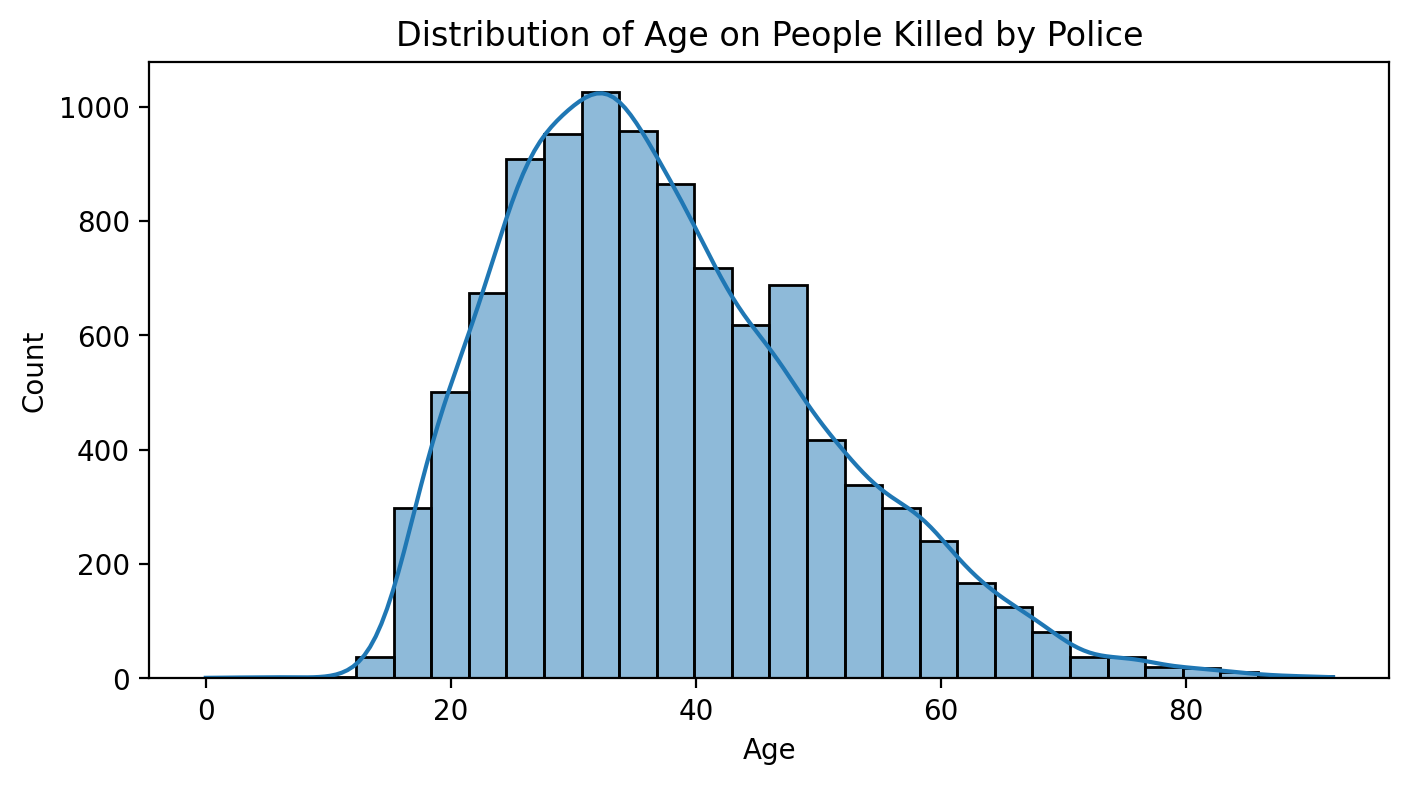

In [65]:
plt.figure(figsize=(8, 4), dpi=200)
sns.histplot(data=df_fatalities, x="age", bins=30, kde=True)
plt.xlabel('Age')
plt.title('Distribution of Age on People Killed by Police')
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions?

In [66]:
# Convert the mixed or unknown to 'Others'
df_fatalities_copy = df_fatalities.copy()

df_fatalities_copy["race"] = df_fatalities_copy["race"].apply(lambda x: x if x in ["A", "W", "H", "B", "O", "N"] else "O")

# Replace the race colummn items with words
df_fatalities_copy["race"] = df_fatalities_copy["race"].replace({"W": "White", "B": "Black", "H": "Hispanic", "A": "Asian",
                                                                 "N": "Native American", "O": "Others"})

df_fatalities_copy.head()

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,location_precision,name,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids
0,3,2015-01-02,point,not,gun,Shelton,Mason,WA,47.25,-123.12,not_available,Tim Elliot,53.00,male,Asian,not_available,True,False,73
1,4,2015-01-02,point,not,gun,Aloha,Washington,OR,45.49,-122.89,not_available,Lewis Lee Lembke,47.00,male,White,not_available,False,False,70
2,5,2015-01-03,move,not,unarmed,Wichita,Sedgwick,KS,37.69,-97.28,not_available,John Paul Quintero,23.00,male,Hispanic,not_available,False,False,238
3,8,2015-01-04,point,not,replica,San Francisco,San Francisco,CA,37.76,-122.42,not_available,Matthew Hoffman,32.00,male,White,not_available,True,False,196
4,9,2015-01-04,point,not,other,Evans,Weld,CO,40.38,-104.69,not_available,Michael Rodriguez,39.00,male,Hispanic,not_available,False,False,473


In [67]:
# Specifying the racial distribution by age
white = df_fatalities_copy.loc[df_fatalities_copy["race"]=="White", "age"]
black = df_fatalities_copy.loc[df_fatalities_copy["race"]=="Black", "age"]
native_american = df_fatalities_copy.loc[df_fatalities_copy["race"]=="Native American", "age"]
asian = df_fatalities_copy.loc[df_fatalities_copy["race"]=="Asian", "age"]
hispanic = df_fatalities_copy.loc[df_fatalities_copy["race"]=="Hispanic", "age"]
others = df_fatalities_copy.loc[df_fatalities_copy["race"]=="Others", "age"]

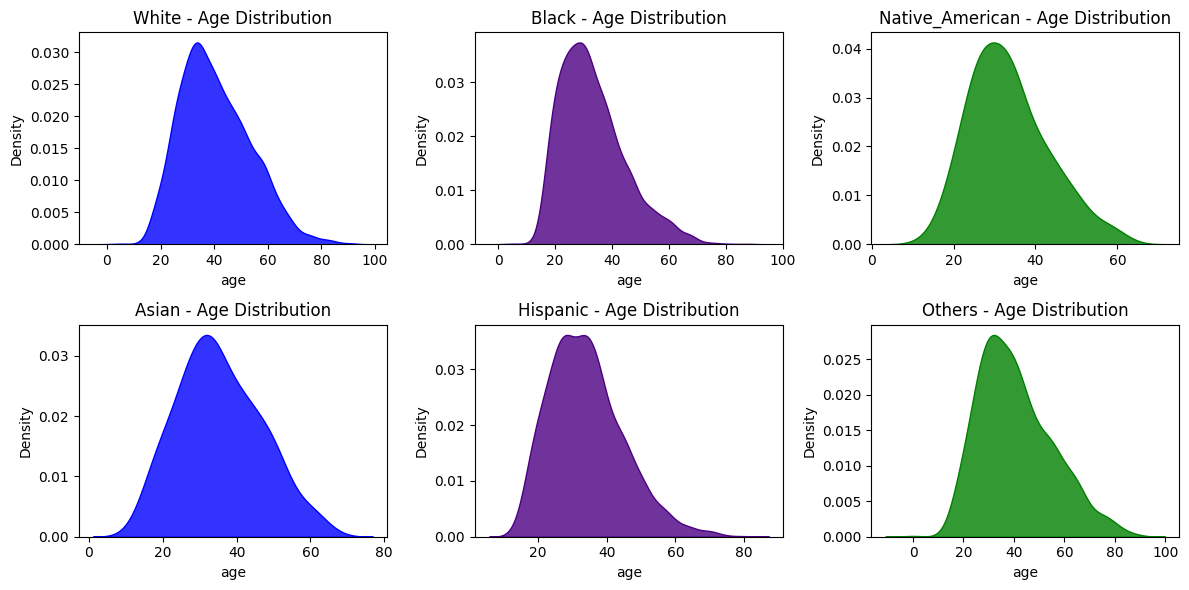

In [68]:
# Plotting the KDE of the racial age distribution
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

# ---- White Racial Distribution ----
sns.kdeplot(x=white, ax=axes[0,0], color='blue', fill=True, alpha=0.8)
axes[0,0].set_title("White - Age Distribution")

# ---- Black Racial Distribution ----
sns.kdeplot(x=black, ax=axes[0,1], color='indigo', fill=True, alpha=0.8)
axes[0,1].set_title("Black - Age Distribution")

# ---- Native_American Racial Distribution ----
sns.kdeplot(x=native_american, ax=axes[0,2], color='green', fill=True, alpha=0.8)
axes[0,2].set_title("Native_American - Age Distribution")

# ---- Asian Distribution ----
sns.kdeplot(x=asian, ax=axes[1,0], color='blue', fill=True, alpha=0.8)
axes[1,0].set_title("Asian - Age Distribution")

# ---- Hispanic Racial Distribution ----
sns.kdeplot(x=hispanic, ax=axes[1,1], color='indigo', fill=True, alpha=0.8)
axes[1,1].set_title("Hispanic - Age Distribution")

# ---- Other Racial Distribution ----
sns.kdeplot(x=others, ax=axes[1,2], color='green', fill=True, alpha=0.8)
axes[1,2].set_title("Others - Age Distribution")

plt.tight_layout()
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race.

In [69]:
# Group the total number of people killed by race
racial_sum = df_fatalities_copy.race.value_counts()
racial_sum

,count
race,
White,4659
Black,2486
Hispanic,1717
Others,1238
Asian,184
Native American,146


In [70]:
# Chart showing the total killings by race
bar = px.bar(x = racial_sum.index,
             y = racial_sum.values,
             title = "Total Killings by Race",
             text = racial_sum.values)
bar.update_layout(xaxis_title="Race",
                  yaxis_title="Total Killings",
                  width=800,
                  height=600)
bar.update_traces(width=0.4, textposition="outside")
bar.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [71]:
# Number of ppl with mental illness
mental_illness = df_fatalities_copy.value_counts("was_mental_illness_related")
mental_illness

,count
was_mental_illness_related,
False,8373
True,2057


In [72]:
# Pie chart showing the pct distribution of ppl with mental illness
mental_illness = mental_illness.rename(index={True: "Yes", False: "No"})
fig = px.pie(labels=mental_illness.index,
             values=mental_illness.values,
             title="Pct of People with Mental Illness",
             names=mental_illness.index)
fig.update_layout(width=600,
                  height=400)
fig.update_traces(textposition="outside", textinfo="percent+label")
fig.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [73]:
df_fatalities.head()

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,location_precision,name,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids
0,3,2015-01-02,point,not,gun,Shelton,Mason,WA,47.25,-123.12,not_available,Tim Elliot,53.00,male,A,not_available,True,False,73
1,4,2015-01-02,point,not,gun,Aloha,Washington,OR,45.49,-122.89,not_available,Lewis Lee Lembke,47.00,male,W,not_available,False,False,70
2,5,2015-01-03,move,not,unarmed,Wichita,Sedgwick,KS,37.69,-97.28,not_available,John Paul Quintero,23.00,male,H,not_available,False,False,238
3,8,2015-01-04,point,not,replica,San Francisco,San Francisco,CA,37.76,-122.42,not_available,Matthew Hoffman,32.00,male,W,not_available,True,False,196
4,9,2015-01-04,point,not,other,Evans,Weld,CO,40.38,-104.69,not_available,Michael Rodriguez,39.00,male,H,not_available,False,False,473


In [74]:
# Top 10 cities with most police killings
top10_cities = df_fatalities.value_counts(["city", "state"]).reset_index(name="count")[:10]
top10_cities

,city,state,count
0,Los Angeles,CA,157
1,Phoenix,AZ,130
2,Houston,TX,125
3,San Antonio,TX,101
4,Las Vegas,NV,86
5,Albuquerque,NM,77
6,Chicago,IL,57
7,Denver,CO,56
8,Tucson,AZ,54
9,Jacksonville,FL,53


In [75]:
# Chart showing the top cities with most police killings
bar = px.bar(x = top10_cities["city"],
             y = top10_cities["count"],
             title = "Top Cities with Police Killings")
bar.update_layout(xaxis_title="Cities",
                  yaxis_title="Number of People Killed",
                  width=800,
                  height=600)
bar.update_traces(width=0.4)
bar.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city.

1. Find the average racial share for each city and state. There are multiple cities that share a city name in a state and multiple states that share a city.

In [76]:
# Sample check of the racial share of one of the top cities
df_share_race_city[
    df_share_race_city["City"].str.contains("Los Angeles", case=False, na=False)]

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
2320,CA,East Los Angeles CDP,50.50,0.60,1.20,0.90,97.10
2474,CA,Green Valley CDP (Los Angeles County),87.70,0.80,1.10,1.20,12.00
2627,CA,Lake Los Angeles CDP,55.70,11.30,1.40,0.90,53.60
2714,CA,Los Angeles city,49.80,9.60,0.70,11.30,48.50
25400,TX,Los Angeles CDP,63.60,9.10,0.00,0.00,100.00


In [77]:
#_________ Create an updated_city column to match the city with the top10 cities ________#
share_race_city = df_share_race_city.copy()   # Copy of df_share_race_city

share_race_city["updated_city"] = None  # Initializing the new city column to None

# Assigning the city name to the updated_city column if found
for city in top10_cities["city"]:
  found_city = share_race_city["City"].str.contains(city, case=False, na=False)
  share_race_city.loc[found_city, "updated_city"] = city


share_race_city.sample(5)

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,updated_city
14781,MT,Fort Shaw CDP,91.10,0.40,1.40,0.70,2.50,None
7055,IL,Port Byron village,98.10,0.20,0.00,0.10,2.80,None
18276,NC,Greenevers town,8.50,81.90,0.00,0.20,8.70,None
3369,CA,Walnut Grove CDP,61.20,1.00,1.60,7.10,43.60,None
28488,WI,Eagle village,98.30,0.10,0.10,0.40,2.10,None


In [78]:
# Sample check showing a city in multiple states
share_race_city[
    share_race_city["City"].str.contains("Los Angeles", case=False, na=False)]

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,updated_city
2320,CA,East Los Angeles CDP,50.50,0.60,1.20,0.90,97.10,Los Angeles
2474,CA,Green Valley CDP (Los Angeles County),87.70,0.80,1.10,1.20,12.00,Los Angeles
2627,CA,Lake Los Angeles CDP,55.70,11.30,1.40,0.90,53.60,Los Angeles
2714,CA,Los Angeles city,49.80,9.60,0.70,11.30,48.50,Los Angeles
25400,TX,Los Angeles CDP,63.60,9.10,0.00,0.00,100.00,Los Angeles


In [79]:
# Inner join on city and state to return only the top 10 valid city–state combinations.

top_city_state = pd.merge(share_race_city,
                          top10_cities,
                          left_on=["updated_city", "Geographic area"],
                          right_on=["city", "state"],
                          how="inner")
top_city_state.head()

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,updated_city,city,state,count
0,AZ,Corona de Tucson CDP,85.20,3.70,0.80,2.20,18.80,Tucson,Tucson,AZ,54
1,AZ,Phoenix city,65.90,6.50,2.20,3.20,40.80,Phoenix,Phoenix,AZ,130
2,AZ,South Tucson city,45.30,3.00,10.70,0.80,78.50,Tucson,Tucson,AZ,54
3,AZ,Tucson city,69.70,5.00,2.70,2.90,41.60,Tucson,Tucson,AZ,54
4,AZ,Tucson Estates CDP,80.00,1.60,2.10,1.10,32.40,Tucson,Tucson,AZ,54


In [80]:
# Rearranging the order of the racial share columns. 9This drops the column not included)
top_city_racial_share = top_city_state[["Geographic area", "City", "updated_city", "share_white", "share_black",
                               "share_native_american", "share_asian", "share_hispanic"]]   # Rearranging the order of the share_race_city

top_city_racial_share.head()

,Geographic area,City,updated_city,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AZ,Corona de Tucson CDP,Tucson,85.20,3.70,0.80,2.20,18.80
1,AZ,Phoenix city,Phoenix,65.90,6.50,2.20,3.20,40.80
2,AZ,South Tucson city,Tucson,45.30,3.00,10.70,0.80,78.50
3,AZ,Tucson city,Tucson,69.70,5.00,2.70,2.90,41.60
4,AZ,Tucson Estates CDP,Tucson,80.00,1.60,2.10,1.10,32.40


In [81]:
# Check one city of top killings
check_city = "Houston"
houston = top_city_racial_share.query("updated_city == @check_city")
houston

,Geographic area,City,updated_city,share_white,share_black,share_native_american,share_asian,share_hispanic
22,TX,Houston city,Houston,50.50,23.70,0.70,6.00,43.80
24,TX,South Houston city,Houston,65.90,1.50,0.90,0.60,88.10


In [82]:
# Average racial composition per city (unweighted by population)
race_cols = ["share_white", "share_black", "share_native_american", "share_asian", "share_hispanic"]   # list of the shared race column

grouped_city = top_city_racial_share.groupby(["updated_city", "Geographic area"])[race_cols].mean().reset_index(level=["updated_city","Geographic area"])

grouped_city

,updated_city,Geographic area,share_white,share_black,share_native_american,share_asian,share_hispanic
0,Albuquerque,NM,74.55,2.00,3.55,1.75,44.30
1,Chicago,IL,57.48,21.77,0.55,3.08,31.38
2,Denver,CO,68.90,10.20,1.40,3.40,31.80
3,Houston,TX,58.20,12.60,0.80,3.30,65.95
4,Jacksonville,FL,75.15,17.30,0.30,3.00,6.00
5,Las Vegas,NV,54.75,15.50,0.75,6.20,35.15
6,Los Angeles,CA,60.92,5.58,1.10,3.58,52.80
7,Phoenix,AZ,65.90,6.50,2.20,3.20,40.80
8,San Antonio,TX,72.60,6.90,0.90,2.40,63.20
9,Tucson,AZ,70.05,3.33,4.08,1.75,42.83


2. Count the number of killings by race in each city and state

In [83]:
# Select city and state in the top10_cities from df_fatalities
top10_race_killings = pd.merge(df_fatalities,
                               top10_cities,
                               on=["city", "state"],
                               how="inner")

# Convert the mixed or unknown race to 'Others'
top10_race_killings["race"] = top10_race_killings["race"].apply(lambda x: x if x in ["A", "W", "H", "B", "O", "N"] else "O")

# Count the number of killings by race,  city and state
top10_race_killings = top10_race_killings.groupby(["city", "state", "race"]).size().unstack(fill_value=0).reset_index()

# replace the race colummn items with words
top10_race_killings = top10_race_killings.rename(
    columns={"W": "White", "B": "Black", "H": "Hispanic", "A": "Asian", "N": "Native_American", "O": "Others"})


top10_race_killings

race,city,state,Asian,Black,Hispanic,Native_American,Others,White
0,Albuquerque,NM,1,3,40,2,16,15
1,Chicago,IL,0,44,10,0,1,2
2,Denver,CO,2,11,18,3,7,15
3,Houston,TX,4,63,36,0,3,19
4,Jacksonville,FL,0,30,4,0,1,18
5,Las Vegas,NV,1,22,24,2,2,35
6,Los Angeles,CA,4,35,95,1,2,20
7,Phoenix,AZ,0,22,52,6,5,45
8,San Antonio,TX,1,10,68,0,2,20
9,Tucson,AZ,0,6,20,0,10,18


In [84]:
# Adding a total_count column to the df
race_cols = ["Others", "Asian", "Black", "Hispanic", "Native_American", "White"]

top10_race_killings["total_count"] = top10_race_killings[race_cols].sum(axis=1)

top10_race_killings = top10_race_killings.sort_values(by="total_count", ascending=False).reset_index(drop=True)
top10_race_killings

race,city,state,Asian,Black,Hispanic,Native_American,Others,White,total_count
0,Los Angeles,CA,4,35,95,1,2,20,157
1,Phoenix,AZ,0,22,52,6,5,45,130
2,Houston,TX,4,63,36,0,3,19,125
3,San Antonio,TX,1,10,68,0,2,20,101
4,Las Vegas,NV,1,22,24,2,2,35,86
5,Albuquerque,NM,1,3,40,2,16,15,77
6,Chicago,IL,0,44,10,0,1,2,57
7,Denver,CO,2,11,18,3,7,15,56
8,Tucson,AZ,0,6,20,0,10,18,54
9,Jacksonville,FL,0,30,4,0,1,18,53


In [85]:
# Check if the top10_city count equals the total_count in the city killings df
is_match = top10_cities["count"] == top10_race_killings["total_count"]
print(is_match.all())


True


### Contrasting the race_share and share_killings

In [86]:
# Convert killings to share %
race_cols = ["Others", "Asian", "Black", "Hispanic", "Native_American", "White"]

for i in race_cols:
    top10_race_killings[f"{i}_kill_share"] = (
        top10_race_killings[i] /
        top10_race_killings["total_count"] * 100
    )

# Drop the count of share and total_count
race_share_fatality = top10_race_killings.drop(columns=race_cols + ["total_count"])
race_share_fatality

race,city,state,Others_kill_share,Asian_kill_share,Black_kill_share,Hispanic_kill_share,Native_American_kill_share,White_kill_share
0,Los Angeles,CA,1.27,2.55,22.29,60.51,0.64,12.74
1,Phoenix,AZ,3.85,0.00,16.92,40.00,4.62,34.62
2,Houston,TX,2.40,3.20,50.40,28.80,0.00,15.20
3,San Antonio,TX,1.98,0.99,9.90,67.33,0.00,19.80
4,Las Vegas,NV,2.33,1.16,25.58,27.91,2.33,40.70
5,Albuquerque,NM,20.78,1.30,3.90,51.95,2.60,19.48
6,Chicago,IL,1.75,0.00,77.19,17.54,0.00,3.51
7,Denver,CO,12.50,3.57,19.64,32.14,5.36,26.79
8,Tucson,AZ,18.52,0.00,11.11,37.04,0.00,33.33
9,Jacksonville,FL,1.89,0.00,56.60,7.55,0.00,33.96


In [87]:
# Merge the race_share_fatality with the average race_share per city. This is to compare fatal_race_share and pop_race_share
merged_share = pd.merge(grouped_city,
                        race_share_fatality,
                        left_on=["updated_city", "Geographic area"],
                        right_on=["city", "state"],
                        how="inner")

merged_share = merged_share.drop(["city", "state"], axis=1)  # Drop the city and state that merged with the new df
merged_share

,updated_city,Geographic area,share_white,share_black,share_native_american,share_asian,share_hispanic,Others_kill_share,Asian_kill_share,Black_kill_share,Hispanic_kill_share,Native_American_kill_share,White_kill_share
0,Albuquerque,NM,74.55,2.00,3.55,1.75,44.30,20.78,1.30,3.90,51.95,2.60,19.48
1,Chicago,IL,57.48,21.77,0.55,3.08,31.38,1.75,0.00,77.19,17.54,0.00,3.51
2,Denver,CO,68.90,10.20,1.40,3.40,31.80,12.50,3.57,19.64,32.14,5.36,26.79
3,Houston,TX,58.20,12.60,0.80,3.30,65.95,2.40,3.20,50.40,28.80,0.00,15.20
4,Jacksonville,FL,75.15,17.30,0.30,3.00,6.00,1.89,0.00,56.60,7.55,0.00,33.96
5,Las Vegas,NV,54.75,15.50,0.75,6.20,35.15,2.33,1.16,25.58,27.91,2.33,40.70
6,Los Angeles,CA,60.92,5.58,1.10,3.58,52.80,1.27,2.55,22.29,60.51,0.64,12.74
7,Phoenix,AZ,65.90,6.50,2.20,3.20,40.80,3.85,0.00,16.92,40.00,4.62,34.62
8,San Antonio,TX,72.60,6.90,0.90,2.40,63.20,1.98,0.99,9.90,67.33,0.00,19.80
9,Tucson,AZ,70.05,3.33,4.08,1.75,42.83,18.52,0.00,11.11,37.04,0.00,33.33


In [88]:
#_____________ Compute the share rate for each race _______________#

# race_share column names from race_city_killings table
race_share_cols = [col for col in race_share_fatality if col not in ["city", "state", "Others_kill_share"]]
race_cols = ["Others", "Asian", "Black", "Hispanic", "Native_American", "White"]


# Create a base share_rate df that will be populated with the share_rates
share_rate = pd.DataFrame(merged_share[["updated_city", "Geographic area"]])


# Loop through each race-specific kill share column to compute the racial share
for col in race_share_cols:
  for race in race_cols:  # Loop through each race category to find matching columns

    if col.lower().startswith(race.lower()):   # Check whether the race name appears in the column name
      # Calculate disparity rate:
      # (share of killings for race) / (share of population for race)  e.g white_kill_share / share_white
      share_rate[f"{race}_rate"] = merged_share[col] / merged_share[f"share_{race.lower()}"]

share_rate


,updated_city,Geographic area,Asian_rate,Black_rate,Hispanic_rate,Native_American_rate,White_rate
0,Albuquerque,NM,0.74,1.95,1.17,0.73,0.26
1,Chicago,IL,0.00,3.55,0.56,0.00,0.06
2,Denver,CO,1.05,1.93,1.01,3.83,0.39
3,Houston,TX,0.97,4.00,0.44,0.00,0.26
4,Jacksonville,FL,0.00,3.27,1.26,0.00,0.45
5,Las Vegas,NV,0.19,1.65,0.79,3.10,0.74
6,Los Angeles,CA,0.71,4.00,1.15,0.58,0.21
7,Phoenix,AZ,0.00,2.60,0.98,2.10,0.53
8,San Antonio,TX,0.41,1.43,1.07,0.00,0.27
9,Tucson,AZ,0.00,3.34,0.86,0.00,0.48


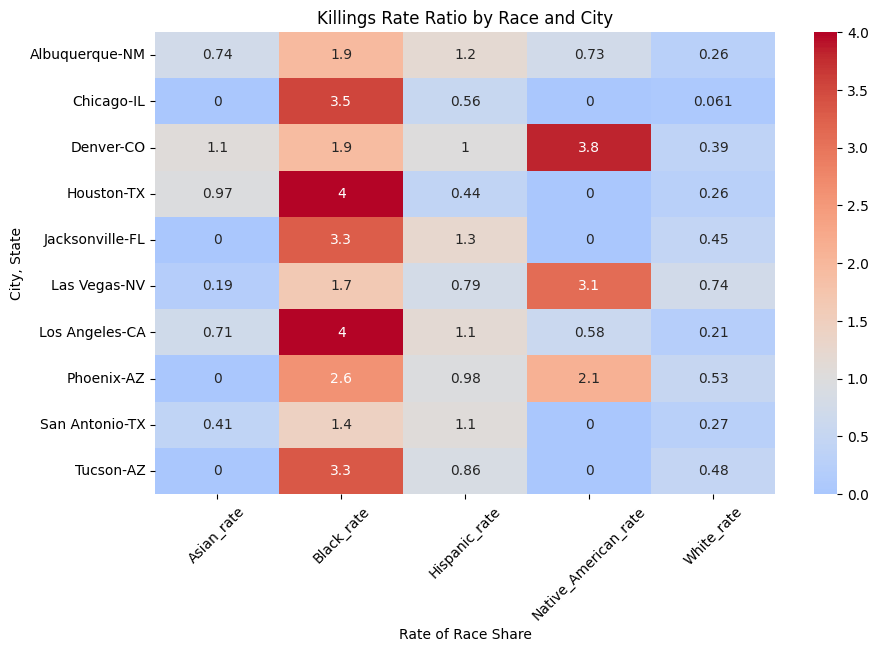

In [89]:
# Heat map of racial share_rates for the top 10 cities
rate_cols = [col for col in share_rate if col not in ["updated_city", "Geographic area"]]

race_heatmap = share_rate.set_index(["updated_city", "Geographic area"])[rate_cols]

plt.figure(figsize=(10,6))
sns.heatmap(race_heatmap, annot=True, cmap="coolwarm", center=1)
plt.title("Killings Rate Ratio by Race and City")
plt.xlabel("Rate of Race Share")
plt.xticks(rotation=45)
plt.ylabel("City, State")
plt.show()


# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty?

In [90]:
# Aggregate the df_fatalities by state
state_killings = df_fatalities.groupby("state").size().reset_index(name="count")

state_killings.head()

,state,count
0,AK,69
1,AL,200
2,AR,143
3,AZ,461
4,CA,1405


In [91]:
# Map of Police Killings by US State
import plotly.graph_objects as go

country_map = px.choropleth(state_killings,
                             locations="state",
                             locationmode="USA-states",
                             scope="usa",
                             color="count",
                             hover_name="state",
                             title="Police Killings by US State",
                             color_continuous_scale=px.colors.sequential.matter
                             )
country_map.add_trace(
    go.Scattergeo(
    locations=state_killings["state"],
    locationmode="USA-states",
    text=state_killings["state"],
    mode="text",
    textfont=dict(size=9, color="white")
    )
)
country_map.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data?

In [92]:
df_fatalities.head()

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,location_precision,name,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids
0,3,2015-01-02,point,not,gun,Shelton,Mason,WA,47.25,-123.12,not_available,Tim Elliot,53.00,male,A,not_available,True,False,73
1,4,2015-01-02,point,not,gun,Aloha,Washington,OR,45.49,-122.89,not_available,Lewis Lee Lembke,47.00,male,W,not_available,False,False,70
2,5,2015-01-03,move,not,unarmed,Wichita,Sedgwick,KS,37.69,-97.28,not_available,John Paul Quintero,23.00,male,H,not_available,False,False,238
3,8,2015-01-04,point,not,replica,San Francisco,San Francisco,CA,37.76,-122.42,not_available,Matthew Hoffman,32.00,male,W,not_available,True,False,196
4,9,2015-01-04,point,not,other,Evans,Weld,CO,40.38,-104.69,not_available,Michael Rodriguez,39.00,male,H,not_available,False,False,473


In [93]:
# Group the fatalities by year and count
fatalities_copy = df_fatalities.copy()
fatalities_copy["date"] = pd.to_datetime(fatalities_copy["date"])  # converting the date column to a datetime datatype
fatalities_copy["year"] = fatalities_copy["date"].dt.year   # creating a year column in the df

year_count = fatalities_copy.groupby("year").size().reset_index(name="count")
year_count


,year,count
0,2015,995
1,2016,959
2,2017,984
3,2018,992
4,2019,993
5,2020,1021
6,2021,1050
7,2022,1097
8,2023,1164
9,2024,1175


In [94]:
# Line graph of yearly fatalities count
a= np.arange(2015, 2025)
year_interval = a[::1]

fig = px.line(year_count,
              x="year",
              y="count",
              title="Number of Fatalities Per Year")
fig.update_layout(xaxis=dict(tickmode="array",
                             tickvals=year_interval,
                             ticktext=year_interval),
                  xaxis_title="Year",
                  xaxis_tickangle=45,
                  yaxis_title="Count of fatalities",
                  xaxis_tickfont_size=11,
                  )

fig.show()

In [95]:
# Count of fatalities by year and state
state_count = fatalities_copy.groupby(["year", "state"]).size().reset_index(name="count")
state_count = state_count.sort_values(["state", "year"], ascending=True).reset_index(drop=True)
state_count

,year,state,count
0,2015,AK,4
1,2016,AK,8
2,2017,AK,8
3,2018,AK,7
4,2019,AK,7
...,...,...,...
497,2020,WY,1
498,2021,WY,3
499,2022,WY,10
500,2023,WY,1


In [96]:
# Line graph showing the various states by the number of fatalities per year
a= np.arange(2015, 2023)
year_interval = a[::1]

fig = px.line(state_count,
              x="year",
              y="count",
              color="state",
              title="Number of Killings by State Over Time")
fig.update_layout(xaxis=dict(tickmode="array",
                             tickvals=year_interval,
                             ticktext=year_interval),
                  xaxis_title="Year",
                  xaxis_tickangle=45,
                  yaxis_title="Number of Killings",
                  xaxis_tickfont_size=11,
                  )

fig.show()

In [97]:
# Group and count the occurrence of racial killing by year
race_count = fatalities_copy.groupby(["year", "race"]).size().reset_index(name="count")
race_count = race_count.sort_values(["year", "race"], ascending=True).reset_index(drop=True)
race_count.tail()

,year,race,count
76,2024,O,9
77,2024,W,397
78,2024,W;B,3
79,2024,W;H,1
80,2024,unknown,304


In [98]:
# Convert the mixed or unknown race to 'Others'
race_count["race"] = race_count["race"].apply(lambda x: x if x in ["A", "W", "H", "B", "O", "N"] else "O")

race_count["race"] = race_count["race"].replace(
    {"W": "White", "B": "Black", "H": "Hispanic", "A": "Asian", "N": "Native_American", "O": "Others"}
    )   # Rename the race column

# Standardise the race and Aggregate the multiple labelled "Others" in the race column
race_count = race_count.groupby(["year", "race"], as_index=False)
race_count = race_count.agg(count=("count", "sum"))

race_count.head()

,year,race,count
0,2015,Asian,17
1,2015,Black,258
2,2015,Hispanic,176
3,2015,Native_American,10
4,2015,Others,29


In [99]:
# Line graph showing the count of various racial killings per year
year_interval = np.arange(2015, 2025)

fig = px.line(race_count,
              x="year",
              y="count",
              color="race",
              title="Number of Police Killings by Race Over Time")
fig.update_layout(xaxis=dict(tickmode="array",
                             tickvals=year_interval,
                             ticktext=year_interval),  #ticktext can be omitted, it is same with tickvals. Used to rename the arr-text
                  xaxis_title="Year",
                  xaxis_tickangle=45,
                  yaxis_title="Number of Killings",
                  xaxis_tickfont_size=11,
                  )

fig.show()

### Cummulative Sum of State and Race

In [100]:
# Aggregating a cummulative sum on each state by year
cumm_state_count = state_count.sort_values(["state", "year"])
cumm_state_count["cummulative_sum"] = cumm_state_count.groupby("state")["count"].cumsum()
cumm_state_count.tail(10)


,year,state,count,cummulative_sum
492,2015,WY,6,6
493,2016,WY,2,8
494,2017,WY,1,9
495,2018,WY,4,13
496,2019,WY,1,14
497,2020,WY,1,15
498,2021,WY,3,18
499,2022,WY,10,28
500,2023,WY,1,29
501,2024,WY,7,36


In [101]:
# Line graph showing the various states by the number of fatalities per year
year_interval = np.arange(2015, 2025)

fig = px.line(cumm_state_count,
              x="year",
              y="cummulative_sum",
              color="state",
              title="Number of Killings by State Over Time")
fig.update_layout(xaxis=dict(tickmode="array",
                             tickvals=year_interval,
                             ticktext=year_interval),
                  xaxis_title="Year",
                  xaxis_tickangle=45,
                  yaxis_title="Number of Killings",
                  xaxis_tickfont_size=11,
                  )

fig.show()

In [102]:
# Aggregating a cummulative sum on each race by year
cumm_race_count = race_count.sort_values(["race", "year"])
cumm_race_count["cummulative_sum"] = cumm_race_count.groupby("race")["count"].cumsum()
cumm_race_count.tail(10)

,year,race,count,cummulative_sum
5,2015,White,505,505
11,2016,White,473,978
17,2017,White,464,1442
23,2018,White,476,1918
29,2019,White,431,2349
35,2020,White,467,2816
41,2021,White,486,3302
47,2022,White,458,3760
53,2023,White,502,4262
59,2024,White,397,4659


In [103]:
# Line graph showing the various races by the number of fatalities per year
year_interval = np.arange(2015, 2025)

fig = px.line(cumm_race_count,
              x="year",
              y="cummulative_sum",
              color="race",
              title="Number of Killings by Race Over Time")
fig.update_layout(xaxis=dict(tickmode="array",
                             tickvals=year_interval,
                             ticktext=year_interval),
                  xaxis_title="Year",
                  xaxis_tickangle=45,
                  yaxis_title="Number of Killings",
                  xaxis_tickfont_size=11,
                  )

fig.show()

### State and Race with Police Killings

In [104]:
# Count of race per state and year with police killings
state_race_count = fatalities_copy.groupby(["year", "state", "race"]).size().reset_index(name="count")

state_race_count["race"] = state_race_count["race"].apply(lambda x: x if x in ["A", "W", "H", "B", "O", "N"] else "O")

state_race_count["race"] = state_race_count["race"].replace(
    {"W": "White", "B": "Black", "H": "Hispanic", "A": "Asian", "N": "Native_American", "O": "Others"}
    )   # Rename the race column

# Standardise the race and Aggregate the multiple labelled "Others" in the race column
state_race_count = state_race_count.groupby(["year", "state", "race"], as_index=False)
state_race_count = state_race_count.agg(count=("count", "sum"))

# Sort the state count by year, state and  race
state_race_count = state_race_count.sort_values(["year", "state", "race"], ascending=True).reset_index(drop=True)

state_race_count

,year,state,race,count
0,2015,AK,Native_American,2
1,2015,AK,White,2
2,2015,AL,Black,6
3,2015,AL,White,11
4,2015,AR,Black,1
...,...,...,...,...
1589,2024,WI,White,11
1590,2024,WV,Others,3
1591,2024,WV,White,6
1592,2024,WY,Others,2


In [105]:
# To show the top 15 states
top15_states = state_race_count.groupby(state_race_count["state"])["count"].sum()[:15]
top15_states = top15_states.index   # Getting the list of the top15 states which is the index of the groupby function

# Filter for the top state and race in the state_race_count
top_state_race = state_race_count[state_race_count["state"].isin(top15_states)]

top_state_race

,year,state,race,count
0,2015,AK,Native_American,2
1,2015,AK,White,2
2,2015,AL,Black,6
3,2015,AL,White,11
4,2015,AR,Black,1
...,...,...,...,...
1461,2024,ID,White,4
1462,2024,IL,Black,9
1463,2024,IL,Hispanic,2
1464,2024,IL,Others,4


In [106]:
# Heat map of states with the number of racial share killings

# Create a multi index
full_index = pd.MultiIndex.from_product(
    [
        top_state_race["year"].unique(),
        top_state_race["state"].unique(),
        top_state_race["race"].unique()
    ],
    names=["year", "state", "race"]
)

# Re-index
top_state_race = (
    top_state_race
    .set_index(["year", "state", "race"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

##_________ Heatmap visual ___________##
fig = px.density_heatmap(
    top_state_race,
    x="race",
    y="state",
    z="count",
    animation_frame="year",   # animation_frame makes a category disapper if it doesn't exist in a frame but re-indexing fixes it
    color_continuous_scale="Reds",
    title="Racial Distribution of Killings Across States by Year"
)

fig.update_layout(coloraxis_colorbar_title="Killings")
fig.update_coloraxes(cmin=0, cmax=top_state_race["count"].max())

# Update the yaxes
fig.update_yaxes(
    categoryorder="array",
    categoryarray=sorted(top_state_race["state"].unique())
)

fig.show()


## Police Agencies and Fatalities

In [107]:
df_agencies

,id,name,type,state,oricodes,total_shootings
0,3145,Abbeville County Sheriff's Office,sheriff,SC,SC00100,1
1,2576,Aberdeen Police Department,local_police,WA,WA01401,1
2,2114,Abilene Police Department,local_police,TX,TX22101,8
3,2088,Abington Township Police Department,local_police,PA,PA04601,1
4,3187,Acadia Parish Sheriff's Office,sheriff,LA,LA00100,1
...,...,...,...,...,...,...
3722,226,Yuba County Sheriff's Office,sheriff,CA,CA05800,6
3723,1874,Yuma County Sheriff's Department,sheriff,AZ,AZ01400,3
3724,1360,Yuma Police Department,local_police,AZ,AZ01405,4
3725,3077,Zapata County Sheriff's Department,sheriff,TX,TX25300,1


### Police agencies with the highest total shootings.
#### What agencies are responsible for the most fatalities? Group by name and count shootings (total_shootings or merge with fatalities). Visualize top 10 with a horizontal bar chart.

In [108]:
# Agencies with the most fatalities
fatal_agencies = df_agencies.groupby("name").agg({"total_shootings": "sum"})
fatal_agencies = fatal_agencies.sort_values("total_shootings", ascending=False).reset_index()

# Top 10 agencies
top10_agencies = fatal_agencies[:10]
top10_agencies

,name,total_shootings
0,Los Angeles Police Department,144
1,U.S. Marshals Service,136
2,Phoenix Police Department,125
3,Los Angeles County Sheriff's Department,117
4,Houston Police Department,88
5,New York Police Department,86
6,San Antonio Police Department,81
7,Las Vegas Metropolitan Police Department,77
8,San Bernardino County Sheriff's Department,63
9,Pennsylvania State Police,63


In [109]:
# Bar chart showing top 10 agencies and total count of people killed
top10_agencies = top10_agencies[::-1]   # To display the chart in descending order
agency_bar = px.bar(x = top10_agencies["total_shootings"],
                 y = top10_agencies["name"],
                 orientation="h",
                 title="Top 10 Police Agencies and Total Shootings")
agency_bar.update_layout(xaxis_title="Total Shootings", yaxis_title="Top 10 Police Agencies")
agency_bar.show()

## How shootings vary by state
#### Compare states to identify where fatal shootings are most common. Visualize with bar chart or choropleth map of US states.

In [110]:
# Fatal shooting among agencies by state
fatal_agency_state = df_agencies.groupby("state").agg({"total_shootings": "sum"})
fatal_agency_state = fatal_agency_state.sort_values("total_shootings", ascending=False).reset_index()
fatal_agency_state.head()

,state,total_shootings
0,CA,1460
1,TX,1085
2,FL,701
3,AZ,480
4,GA,434


In [111]:
# Map of Agency Killings by US State

agency_map = px.choropleth(fatal_agency_state,
                           locations="state",
                           locationmode="USA-states",
                           scope="usa",
                           color="total_shootings",
                           hover_name="state",
                           title="Police Agency Killings by US State",
                           color_continuous_scale=px.colors.sequential.matter
                           )
agency_map.show()

## Agency Shootings

#### Which cities have dominant agency fatalities? Visualize with treemap or grouped bar chart.

In [112]:
df_agencies.head()

,id,name,type,state,oricodes,total_shootings
0,3145,Abbeville County Sheriff's Office,sheriff,SC,SC00100,1
1,2576,Aberdeen Police Department,local_police,WA,WA01401,1
2,2114,Abilene Police Department,local_police,TX,TX22101,8
3,2088,Abington Township Police Department,local_police,PA,PA04601,1
4,3187,Acadia Parish Sheriff's Office,sheriff,LA,LA00100,1


In [113]:
# Checking the datatype of the agency_ids in the fatalities table
print(f"The datatype of agency_ids is '{df_fatalities["agency_ids"].dtype}'\n")

# Getting the rows that cannot be converted to numeric
object_ids = df_fatalities[pd.to_numeric(df_fatalities["agency_ids"], errors="coerce").isna()]
object_ids["agency_ids"].head()

The datatype of agency_ids is 'object'



,agency_ids
18,491;492
31,228;229
61,1953;109
66,174;175
71,512;511


#### Multiple agency_ids are linked to a fatality. Split these agency_ids into separate rows on the df_fatality table




In [114]:
# Split the agency column
df_fatalities["agency_ids"] = df_fatalities["agency_ids"].str.split(";")

# Normalise/explode the agency_ids list into separate rows with its respective ids
df_fatalities = df_fatalities.explode("agency_ids")

# Remove any presence of whitespaces
df_fatalities["agency_ids"] = df_fatalities["agency_ids"].str.strip()

# Convert to numeric datatype
df_fatalities["agency_ids"] = pd.to_numeric(df_fatalities["agency_ids"], errors="coerce")


df_fatalities.sample(5)

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,location_precision,name,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids
9750,10568,2024-05-31,shoot,not,gun,Saybrook Township,Ashtabula,OH,NaN,NaN,unknown,John Perry,63.00,male,W,photo,False,False,"1,408.00"
10243,11092,2024-11-01,point,not,gun,Rapid City,Pennington,SD,44.10,-103.22,intersection,Jesse War Bonnet,27.00,male,unknown,unknown,False,False,617.00
2128,2373,2017-02-23,shoot,not,gun,Fairfax,Osage,OK,36.57,-96.70,not_available,Kenneth Robertson,54.00,male,unknown,unknown,False,False,"1,669.00"
4033,4483,2019-02-06,shoot,car,gun,Stone County,unknown,MS,30.80,-89.17,not_available,Miles Dylan Cooper,25.00,male,W,not_available,False,True,854.00
8204,8927,2023-02-03,threat,foot,gun,North Vernon,Jennings,IN,39.01,-85.69,block,Devin C. Lark,29.00,male,W,public_record,False,False,"14,287.00"


In [115]:
#___________ Add agency name to df_fatalities table by merging on agency ids ___________#

df_fatalities_copy = df_fatalities.copy()

agency_lookup = df_agencies[["id", "name", "type", "state"]]
agency_lookup = agency_lookup.rename(columns={"id": "agency_ids",
                                            "name": "agency_name",
                                            "type": "agency_type",
                                            "state": "agency_state"})

# Merge the agency id, name, type and state on the df_fatalities table using the agency ids
df_fatalities_copy = pd.merge(df_fatalities_copy,
                              agency_lookup,
                              on=["agency_ids"],
                              how="left")

df_fatalities_copy.head()

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,...,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids,agency_name,agency_type,agency_state
0,3,2015-01-02,point,not,gun,Shelton,Mason,WA,47.25,-123.12,...,53.00,male,A,not_available,True,False,73.00,Mason County Sheriff's Office,sheriff,WA
1,4,2015-01-02,point,not,gun,Aloha,Washington,OR,45.49,-122.89,...,47.00,male,W,not_available,False,False,70.00,Washington County Sheriff's Office,sheriff,OR
2,5,2015-01-03,move,not,unarmed,Wichita,Sedgwick,KS,37.69,-97.28,...,23.00,male,H,not_available,False,False,238.00,Wichita Police Department,local_police,KS
3,8,2015-01-04,point,not,replica,San Francisco,San Francisco,CA,37.76,-122.42,...,32.00,male,W,not_available,True,False,196.00,San Francisco Police Department,local_police,CA
4,9,2015-01-04,point,not,other,Evans,Weld,CO,40.38,-104.69,...,39.00,male,H,not_available,False,False,473.00,Evans Police Department,local_police,CO


In [116]:
# Count of dominant agencies in cities
num_agencies_in_cities = df_fatalities_copy.groupby(["city", "state"])["agency_name"].nunique()
num_agencies_in_cities = num_agencies_in_cities.sort_values(ascending=False).reset_index(name="num_agencies")
num_agencies_in_cities

,city,state,num_agencies
0,Houston,TX,12
1,Los Angeles,CA,12
2,San Antonio,TX,11
3,Atlanta,GA,10
4,Denver,CO,9
...,...,...,...
4441,Zebulon,NC,1
4442,Zanesville,OH,1
4443,Airway Heights,WA,1
4444,Aiken County,SC,1


In [117]:
# Treemap Chart of cities with agencies dominantly involved in fatal shootings
num_agencies_in_cities = num_agencies_in_cities.query("city != 'unknown'")
agencies_in_cities = num_agencies_in_cities[:20]
fig = px.treemap(agencies_in_cities,
                 path=["city"],
                 values="num_agencies",
                 color="num_agencies",
                 hover_data=["city"])

fig.update_layout(title="Top 20 Cities by Number of Agencies Involved in Fatal Shootings")

fig.show()

## How does agency type relate to shootings?

#### Determine if certain types of agencies are more involved in fatal shootings. Visualize with pie chart for proportions.

In [118]:
# Count of agency type
agency_type_count = df_fatalities_copy["agency_type"].value_counts().reset_index()
agency_type_count = agency_type_count.rename(columns={"count": "fatal_count"})
agency_type_count

,agency_type,fatal_count
0,local_police,6827
1,sheriff,3205
2,state_police,810
3,federal,285
4,local_other,67
5,state_other,38
6,other,31


In [119]:
# Pie Chart showing proportions of fatalities by agencies
pie = px.pie(labels=agency_type_count.agency_type,
             values=agency_type_count.fatal_count,
             title="Proportion of Total shootings by Agency Type",
             names=agency_type_count.agency_type,
             color_discrete_sequence=px.colors.sequential.matter
)
pie.update_traces(textposition="auto",
                  textinfo="percent+label",
                  textfont_size=15,
                  hovertemplate="Label: %{label}<br>" + "Shootings: %{value}<br>" + "Percentage: %{percent}")
pie.show()

## Yearly trends in shootings for top agencies
#### Do shootings increase or decrease over time? Merge fatalities with agency_id to get years. Group by year and name. Visualize with line chart (one line per agency)

In [120]:
# Create a copy of the df_fatalities_copy
agency_shootings = df_fatalities_copy.copy()
df_fatalities_copy.head()

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,...,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids,agency_name,agency_type,agency_state
0,3,2015-01-02,point,not,gun,Shelton,Mason,WA,47.25,-123.12,...,53.00,male,A,not_available,True,False,73.00,Mason County Sheriff's Office,sheriff,WA
1,4,2015-01-02,point,not,gun,Aloha,Washington,OR,45.49,-122.89,...,47.00,male,W,not_available,False,False,70.00,Washington County Sheriff's Office,sheriff,OR
2,5,2015-01-03,move,not,unarmed,Wichita,Sedgwick,KS,37.69,-97.28,...,23.00,male,H,not_available,False,False,238.00,Wichita Police Department,local_police,KS
3,8,2015-01-04,point,not,replica,San Francisco,San Francisco,CA,37.76,-122.42,...,32.00,male,W,not_available,True,False,196.00,San Francisco Police Department,local_police,CA
4,9,2015-01-04,point,not,other,Evans,Weld,CO,40.38,-104.69,...,39.00,male,H,not_available,False,False,473.00,Evans Police Department,local_police,CO


In [121]:
# Create a year column in agency_shootings df
agency_shootings["year"] = pd.to_datetime(df_fatalities_copy["date"]).dt.year

# Group the agency by year and name
agency_shooting_count = agency_shootings.groupby(["year", "agency_name"]).size().reset_index(name="fatal_count")
agency_shooting_count = agency_shooting_count.sort_values(["year", "fatal_count"], ascending=[True, False]).reset_index(drop=True)
agency_shooting_count

,year,agency_name,fatal_count
0,2015,Los Angeles Police Department,21
1,2015,U.S. Marshals Service,18
2,2015,Los Angeles County Sheriff's Department,15
3,2015,Las Vegas Metropolitan Police Department,11
4,2015,Houston Police Department,10
...,...,...,...
7150,2024,Wright County Sheriff's Office,1
7151,2024,Yavapai County Sheriff's Department,1
7152,2024,Yuba City Police Department,1
7153,2024,Yuba County Sheriff's Office,1


In [122]:
# Get the list of the Top20 agencies with fatalities
top20_agencies = agency_shooting_count.groupby(agency_shooting_count["agency_name"])["fatal_count"].sum()
top20_agencies = top20_agencies.sort_values(ascending=False)
top20_agencies = top20_agencies.index[:20]   # top20 agencies
print(f"The top 20 agencies: {top20_agencies}\n")


# Get the agency_shooting_count for the top20 agencies
new_agency_shooting_count = agency_shooting_count[agency_shooting_count["agency_name"].isin(top20_agencies)]
new_agency_shooting_count = new_agency_shooting_count.reset_index(drop=True)
new_agency_shooting_count

The top 20 agencies: Index(['Los Angeles Police Department', 'U.S. Marshals Service',
       'Phoenix Police Department', 'Los Angeles County Sheriff's Department',
       'Houston Police Department', 'New York Police Department',
       'San Antonio Police Department',
       'Las Vegas Metropolitan Police Department', 'Pennsylvania State Police',
       'San Bernardino County Sheriff's Department',
       'California Highway Patrol', 'Riverside County Sheriff's Department',
       'Texas Department of Public Safety', 'Columbus Police Department',
       'Chicago Police Department', 'Jacksonville Sheriff's Office',
       'Albuquerque Police Department', 'Kentucky State Police',
       'Kansas City Police Department', 'Austin Police Department'],
      dtype='object', name='agency_name')



,year,agency_name,fatal_count
0,2015,Los Angeles Police Department,21
1,2015,U.S. Marshals Service,18
2,2015,Los Angeles County Sheriff's Department,15
3,2015,Las Vegas Metropolitan Police Department,11
4,2015,Houston Police Department,10
...,...,...,...
195,2024,Kansas City Police Department,4
196,2024,Kentucky State Police,4
197,2024,Riverside County Sheriff's Department,4
198,2024,Chicago Police Department,3


In [123]:
# Facet line graph showing the count of fatalities by agency per year

fig = px.line(
    new_agency_shooting_count,
    x="year",
    y="fatal_count",
    facet_col="agency_name",
    facet_col_wrap=4,
    facet_col_spacing=0.02,
    facet_row_spacing=0.06,
    title="Number of Fatalities by Agencies per Year"
)

fig.update_layout(height=600, margin=dict(t=100))

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))   # Remove the "agency_name=" prefix on each chart title

fig.show()

## Which agency-state combinations have the highest shootings?
#### Identifies both geographic and organizational responsibility. Group by state and name → sum shootings. Visualize with treemap.

In [124]:
df_fatalities_copy.head()

,id,date,threat_type,flee_status,armed_with,city,county,state,latitude,longitude,...,age,gender,race,race_source,was_mental_illness_related,body_camera,agency_ids,agency_name,agency_type,agency_state
0,3,2015-01-02,point,not,gun,Shelton,Mason,WA,47.25,-123.12,...,53.00,male,A,not_available,True,False,73.00,Mason County Sheriff's Office,sheriff,WA
1,4,2015-01-02,point,not,gun,Aloha,Washington,OR,45.49,-122.89,...,47.00,male,W,not_available,False,False,70.00,Washington County Sheriff's Office,sheriff,OR
2,5,2015-01-03,move,not,unarmed,Wichita,Sedgwick,KS,37.69,-97.28,...,23.00,male,H,not_available,False,False,238.00,Wichita Police Department,local_police,KS
3,8,2015-01-04,point,not,replica,San Francisco,San Francisco,CA,37.76,-122.42,...,32.00,male,W,not_available,True,False,196.00,San Francisco Police Department,local_police,CA
4,9,2015-01-04,point,not,other,Evans,Weld,CO,40.38,-104.69,...,39.00,male,H,not_available,False,False,473.00,Evans Police Department,local_police,CO


In [125]:
# Get the agency name and the sum of fatalities per state
agency_state_count = df_fatalities_copy.groupby(["agency_state", "agency_name"]).agg({"city": "count"}).reset_index()
agency_state_count = agency_state_count.rename(columns={"agency_state": "state", "city": "fatal_count"})
agency_state_count = agency_state_count.sort_values(by=["state", "fatal_count"], ascending=[True, False])
agency_state_count.head(10)

,state,agency_name,fatal_count
0,AK,Alaska State Troopers,33
2,AK,Anchorage Police Department,20
5,AK,Fairbanks Police Department,7
12,AK,Wasilla Police Department,5
6,AK,Juneau Police Department,3
7,AK,North Slope Borough Police Department,2
10,AK,U.S. Marshals District of Alaska,2
1,AK,Alaska Wildlife Troopers,1
3,AK,Chefornak Tribal Police Department,1
4,AK,Fairbanks International Airport Police Department,1


In [126]:
# Aggregate the fatal count by state
state_count = agency_state_count.groupby("state").agg({"fatal_count": "sum"}).reset_index()
state_count = state_count.sort_values("fatal_count", ascending=False)

# Get the top 15 states
top15_state = state_count[:15]
print(f"The top15 states are: {list(top15_state.state)}\n")

# Get the top15 states in the agency_state_count table
agency_state_count = agency_state_count[agency_state_count["state"].isin(top15_state["state"])]
agency_state_count

The top15 states are: ['CA', 'TX', 'FL', 'AZ', 'GA', 'CO', 'OH', 'NC', 'TN', 'WA', 'MO', 'OK', 'NM', 'PA', 'IN']



,state,agency_name,fatal_count
252,AZ,Phoenix Police Department,125
267,AZ,Tucson Police Department,41
243,AZ,Mesa Police Department,38
229,AZ,Glendale Police Department,19
207,AZ,Arizona Department of Public Safety,18
...,...,...,...
3551,WA,Walla Walla Police Department,1
3552,WA,Wapato Police Department,1
3555,WA,Whitman County Sheriff's Office,1
3556,WA,Woodland Police Department,1


In [127]:
# Treemap Chart of states with highest fatalities and their agencies

fig = px.treemap(agency_state_count,
                 path=[agency_state_count.state, agency_state_count.agency_name],
                 values="fatal_count",
                 color="fatal_count",
                 hover_data="state")

fig.update_layout(title="Highest Fatality States and their Agencies")

fig.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).